In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("../data/view/fourth_down_with_features.csv")
print(df.shape)
print(df.columns.tolist())

(35871, 45)
['game_id', 'season', 'week', 'game_date', 'home_team', 'away_team', 'posteam', 'defteam', 'qtr', 'game_seconds_remaining', 'yardline_100', 'ydstogo', 'score_differential', 'roof', 'temp', 'wind', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'epa', 'wp', 'wpa', 'decision', 'go_converted', 'go_failed', 'fg_made', 'kick_distance', 'punt_attempt', 'field_goal_attempt', 'yards_gained', 'touchback', 'drive', 'fixed_drive', 'order_sequence', 'play_id', 'ydstogo_bin', 'yardline_bin', 'go_conv_rate', 'go_attempts', 'go_stop_rate', 'go_faced', 'epa_per_drive_roll6', 'success_rate_roll6', 'points_per_drive_roll6']


In [3]:
punts = df[df["punt_attempt"] == 1].copy()
print(punts.shape)
print(punts[["yardline_100", "yards_gained", "touchback", "posteam", "season", "week"]].head(10))

(19640, 45)
    yardline_100  yards_gained  touchback posteam  season  week
0           39.0           0.0        0.0     JAX    2017     5
2           56.0           0.0        0.0     CAR    2017     8
3           53.0           0.0        0.0     CAR    2017     9
4           46.0           0.0        0.0     CAR    2017     9
5           46.0           0.0        0.0     PHI    2017    13
6           42.0           0.0        0.0     DAL    2017    13
7           46.0           0.0        0.0      KC    2017    14
8           73.0           0.0        0.0     SEA    2017    15
9           74.0           0.0        0.0     SEA    2017    15
10          74.0           0.0        0.0     SEA    2017    15


In [4]:
print(punts[["yardline_100", "kick_distance", "touchback", "posteam", "season", "week"]].head(10))
print(punts["kick_distance"].describe())

    yardline_100  kick_distance  touchback posteam  season  week
0           39.0           35.0        0.0     JAX    2017     5
2           56.0           48.0        0.0     CAR    2017     8
3           53.0           50.0        0.0     CAR    2017     9
4           46.0           38.0        0.0     CAR    2017     9
5           46.0           43.0        0.0     PHI    2017    13
6           42.0           41.0        0.0     DAL    2017    13
7           46.0           13.0        0.0      KC    2017    14
8           73.0           46.0        0.0     SEA    2017    15
9           74.0           41.0        0.0     SEA    2017    15
10          74.0           61.0        0.0     SEA    2017    15
count    19640.000000
mean        45.919959
std          9.785770
min         -1.000000
25%         40.000000
50%         46.000000
75%         52.000000
max         84.000000
Name: kick_distance, dtype: float64


In [5]:
punts["opponent_start"] = 100 - punts["yardline_100"] + punts["kick_distance"]
punts.loc[punts["touchback"] == 1, "opponent_start"] = 80

print(punts["opponent_start"].describe())

count    19640.000000
mean        78.688646
std         12.248914
min          0.000000
25%         72.000000
50%         80.000000
75%         88.000000
max        105.000000
Name: opponent_start, dtype: float64


In [6]:
punts = punts[(punts["kick_distance"] > 0) & (punts["opponent_start"] <= 100)].copy()

print(punts.shape)
print(punts["opponent_start"].describe())

(19530, 46)
count    19530.000000
mean        78.934921
std         11.726626
min         15.000000
25%         72.000000
50%         80.000000
75%         88.000000
max        100.000000
Name: opponent_start, dtype: float64


In [7]:
game_punt_stats = punts.groupby(["posteam", "season", "week"]).agg(
    avg_punt_distance=("kick_distance", "mean"),
    inside_twenty_rate=("opponent_start", lambda x: (x > 80).mean())
).reset_index()

print(game_punt_stats.head(10))

  posteam  season  week  avg_punt_distance  inside_twenty_rate
0     ARI    2016     1          36.000000            0.600000
1     ARI    2016     2          46.500000            0.500000
2     ARI    2016     3          35.333333            0.333333
3     ARI    2016     4          42.250000            0.500000
4     ARI    2016     5          42.444444            0.666667
5     ARI    2016     6          40.000000            0.400000
6     ARI    2016     7          38.166667            0.500000
7     ARI    2016     8          43.166667            0.166667
8     ARI    2016    10          44.250000            0.250000
9     ARI    2016    11          44.800000            0.600000


### Rolling Average Compute

In [8]:
game_punt_stats = game_punt_stats.sort_values(["posteam","season","week"]).copy()

game_punt_stats["punt_distance_roll6"] = (game_punt_stats.groupby("posteam")["avg_punt_distance"].transform(lambda x: x.shift(1).rolling(6, min_periods = 1).mean()))

game_punt_stats["inside_twenty_rate_roll6"] = (game_punt_stats.groupby("posteam")["inside_twenty_rate"].transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean()))

print(game_punt_stats.head(10))

  posteam  season  week  avg_punt_distance  inside_twenty_rate  \
0     ARI    2016     1          36.000000            0.600000   
1     ARI    2016     2          46.500000            0.500000   
2     ARI    2016     3          35.333333            0.333333   
3     ARI    2016     4          42.250000            0.500000   
4     ARI    2016     5          42.444444            0.666667   
5     ARI    2016     6          40.000000            0.400000   
6     ARI    2016     7          38.166667            0.500000   
7     ARI    2016     8          43.166667            0.166667   
8     ARI    2016    10          44.250000            0.250000   
9     ARI    2016    11          44.800000            0.600000   

   punt_distance_roll6  inside_twenty_rate_roll6  
0                  NaN                       NaN  
1            36.000000                  0.600000  
2            41.250000                  0.550000  
3            39.277778                  0.477778  
4            40.02

In [9]:
punts = punts.merge(game_punt_stats[["posteam", "season", "week", "punt_distance_roll6", "inside_twenty_rate_roll6"]],on=["posteam", "season", "week"], how="left")

print(punts.shape)
print(punts[["yardline_100", "punt_distance_roll6", "inside_twenty_rate_roll6", "opponent_start"]].head(10))

(19530, 48)
   yardline_100  punt_distance_roll6  inside_twenty_rate_roll6  opponent_start
0          39.0            47.623611                  0.448611            96.0
1          56.0            44.038889                  0.338889            92.0
2          53.0            45.526984                  0.374603            97.0
3          46.0            45.526984                  0.374603            92.0
4          46.0            48.500000                  0.444444            97.0
5          42.0            43.858333                  0.616667            99.0
6          46.0            45.736111                  0.516667            67.0
7          73.0            44.938889                  0.323611            73.0
8          74.0            44.938889                  0.323611            67.0
9          74.0            44.938889                  0.323611            87.0


In [10]:
punts = punts.dropna(subset=["punt_distance_roll6", "inside_twenty_rate_roll6"]).copy()
print(punts.shape)

(19388, 48)


### Train/Test Split

In [11]:
features = ["yardline_100", "punt_distance_roll6", "inside_twenty_rate_roll6"]
target = "opponent_start"

train = punts[punts["season"] <= 2022]
test = punts[punts["season"] >= 2023]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

model = xgb.XGBRegressor(
    n_estimators = 300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained")

Training rows: 15099
Testing rows: 4289
Model trained


In [12]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f} yards")
print(f"MAE: {mae:.2f} yards")

importance = model.feature_importances_
for name, score in zip(features, importance):
    print(f"{name}: {score:.3f}")

import os
os.makedirs("../models", exist_ok = True)
model.save_model("../models/punt_outcome_xgb.json")
print("Model saved")

RMSE: 7.51 yards
MAE: 5.91 yards
yardline_100: 0.943
punt_distance_roll6: 0.032
inside_twenty_rate_roll6: 0.025
Model saved


### Presentation Visuals

In [13]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

# --- Dark theme matching the other slides ---
DARK = "#0d1f17"
ACCENT = "#4ade80"
GOLD = "#f5c518"
DANGER = "#f87171"
MUTED = "#8aaa96"
GRID = "#1e4a2e"

plt.rcParams.update({
    "figure.facecolor": DARK,
    "axes.facecolor": "#0f2219",
    "axes.edgecolor": "#2d5a3d",
    "axes.labelcolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": "#f8f8f2",
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "monospace",
})

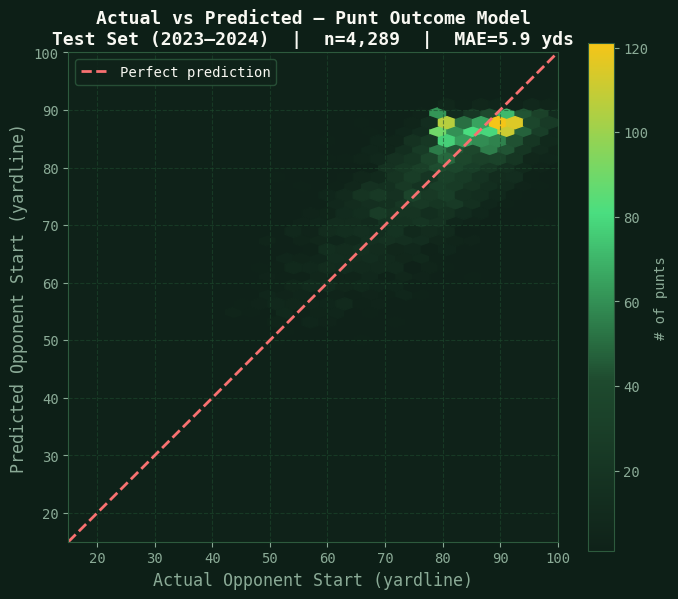

In [14]:
# PLOT 1: Actual vs Predicted (hexbin density)
fig, ax = plt.subplots(figsize=(7, 6))

cmap = LinearSegmentedColormap.from_list("custom", ["#0f2219", "#1e4a2e", ACCENT, GOLD])
hb = ax.hexbin(y_test.values, y_pred, gridsize=25, cmap=cmap, mincnt=1)

# Perfect prediction line
ax.plot([15, 100], [15, 100], "--", color=DANGER, lw=2, label="Perfect prediction")

ax.set_xlabel("Actual Opponent Start (yardline)", fontsize=12)
ax.set_ylabel("Predicted Opponent Start (yardline)", fontsize=12)
ax.set_title("Actual vs Predicted — Punt Outcome Model\n"
             f"Test Set (2023–2024)  |  n={len(y_test):,}  |  MAE={mae:.1f} yds",
             fontsize=13, fontweight="bold")
ax.legend(facecolor="#0f2219", edgecolor="#2d5a3d", labelcolor="#f8f8f2", fontsize=10)
ax.set_xlim(15, 100)
ax.set_ylim(15, 100)
ax.set_aspect("equal")
ax.grid(True)

cb = fig.colorbar(hb, ax=ax, label="# of punts")
cb.ax.yaxis.label.set_color(MUTED)
cb.ax.tick_params(colors=MUTED)

plt.tight_layout()
plt.savefig("punt_actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()

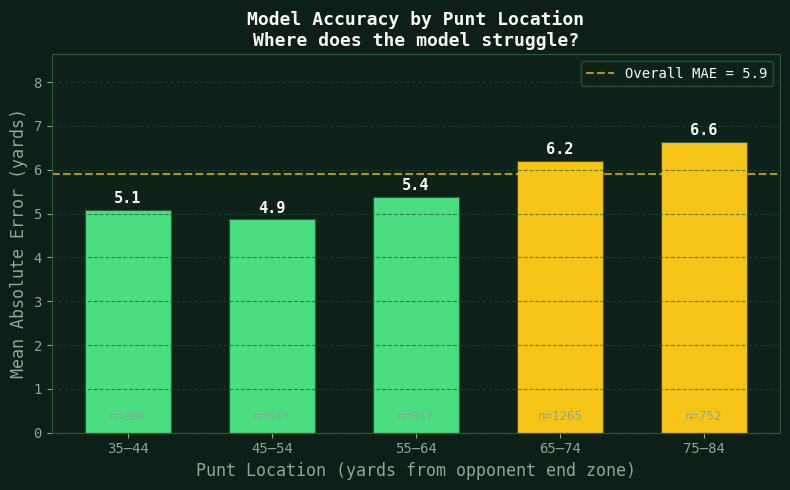

In [15]:
# PLOT 2: Prediction error by field zone
test_df = test.copy()
test_df["y_pred"] = y_pred
test_df["error"] = test_df["opponent_start"] - test_df["y_pred"]
test_df["abs_error"] = test_df["error"].abs()

# Bucket by punt location
bins = [25, 35, 45, 55, 65, 75, 85]
labels = ["25–34", "35–44", "45–54", "55–64", "65–74", "75–84"]
test_df["punt_zone"] = pd.cut(test_df["yardline_100"], bins=bins, labels=labels, right=False)

zone_stats = test_df.groupby("punt_zone", observed=True).agg(
    mae=("abs_error", "mean"),
    count=("abs_error", "count")
).reset_index()
zone_stats = zone_stats[zone_stats["count"] >= 10]

colors = [ACCENT if m < 6 else GOLD if m < 7 else DANGER for m in zone_stats["mae"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(zone_stats["punt_zone"], zone_stats["mae"],
              color=colors, edgecolor="#2d5a3d", linewidth=0.8, width=0.6)

for bar, row in zip(bars, zone_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{row.mae:.1f}", ha="center", fontsize=11, fontweight="bold", color="#f8f8f2")
    ax.text(bar.get_x() + bar.get_width() / 2, 0.3,
            f"n={row.count}", ha="center", fontsize=9, color=MUTED)

ax.axhline(mae, color=GOLD, linestyle="--", lw=1.5, alpha=0.7, label=f"Overall MAE = {mae:.1f}")
ax.set_xlabel("Punt Location (yards from opponent end zone)", fontsize=12)
ax.set_ylabel("Mean Absolute Error (yards)", fontsize=12)
ax.set_title("Model Accuracy by Punt Location\n"
             "Where does the model struggle?", fontsize=13, fontweight="bold")
ax.legend(facecolor="#0f2219", edgecolor="#2d5a3d", labelcolor="#f8f8f2", fontsize=10)
ax.set_ylim(0, max(zone_stats["mae"]) + 2)
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("punt_error_by_zone.png", dpi=200, bbox_inches="tight")
plt.show()

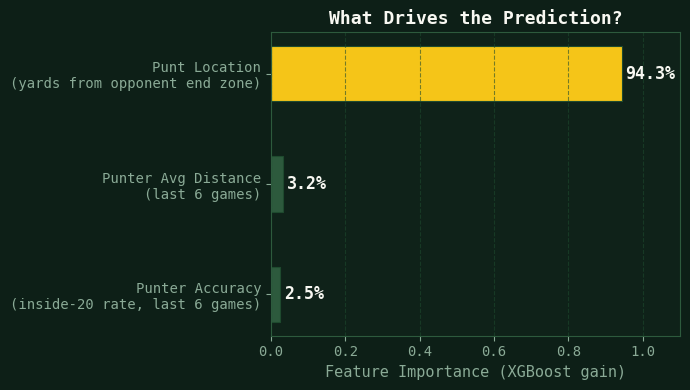

In [16]:
# PLOT 3: Feature importance
fig, ax = plt.subplots(figsize=(7, 4))

feat_imp = sorted(zip(features, importance), key=lambda x: x[1])
names = [f[0] for f in feat_imp]
scores = [f[1] for f in feat_imp]

# Friendly labels
friendly = {
    "yardline_100": "Punt Location\n(yards from opponent end zone)",
    "punt_distance_roll6": "Punter Avg Distance\n(last 6 games)",
    "inside_twenty_rate_roll6": "Punter Accuracy\n(inside-20 rate, last 6 games)"
}
display_names = [friendly.get(n, n) for n in names]
bar_colors = [GOLD if s == max(scores) else "#2d5a3d" for s in scores]

bars = ax.barh(display_names, scores, color=bar_colors, edgecolor="#1e4a2e", linewidth=0.8, height=0.5)
for bar, val in zip(bars, scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", ha="left", fontsize=12, fontweight="bold")

ax.set_xlabel("Feature Importance (XGBoost gain)", fontsize=11)
ax.set_title("What Drives the Prediction?", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.1)
ax.grid(True, axis="x")

plt.tight_layout()
plt.savefig("punt_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()